In [ ]:
from math import factorial

def coeff( nmax ):
    Cs = []

    k = 0
    for ni in range(nmax):
        if (ni%2 == 0):
            Cs.append((-1)**k)
            k += 1
        else:
            Cs.append(0)
    return Cs

Cs = coeff(100)

def f_approximated(x, nmax):
    return sum([ 1/factorial(n)*Cs[n]*x**n for n in range(nmax) ])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

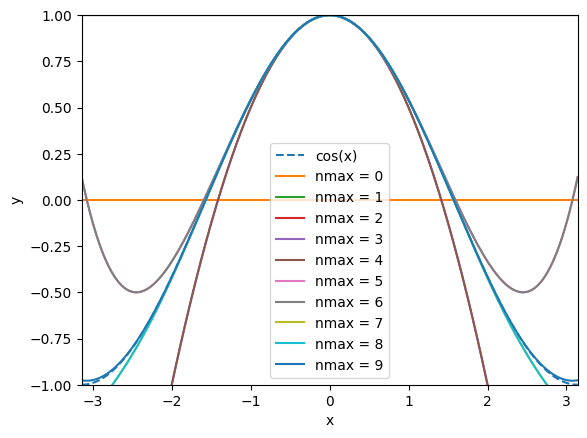

In [ ]:
x = np.linspace(-np.pi, np.pi, 200)
y_real = np.cos(x)

plt.plot( x, y_real, "--", label = "cos(x)" )
plt.xlabel("x")
plt.ylabel("y")

for n_maxi in range(10):
    y_approx = [f_approximated(xi, n_maxi) for xi in x]
    plt.plot( x, y_approx, label = f"nmax = {n_maxi}" )

plt.axis([-np.pi, np.pi, -1, 1])
plt.legend()
plt.show()

## Fractal de Serpinsky

In [ ]:
!pip install pyx

In [ ]:
from pyx import *

In [ ]:
c = canvas.canvas()
def draw_triangle(x1, y1, x2, y2, x3, y3):
    c.stroke( path.line(x1,y1, x2,y2) )
    c.stroke( path.line(x2,y2, x3,y3) )
    c.stroke( path.line(x3,y3, x1,y1) )

def serpinsky_carpet( x, y, size, depth):
    if depth == 0:
        draw_triangle( x, y, x+size, y,  x + size/2, y + np.sqrt(3)/2*size )
    else:
        serpinsky_carpet( x, y, size/2, depth-1 )
        serpinsky_carpet( x + size/2, y, size/2, depth-1)
        serpinsky_carpet( x + size/4, y + size*np.sqrt(3)/4, size/2, depth-1)

In [ ]:
serpinsky_carpet( 0, 0, 100, 10 )
c.writePDFfile("triangle")

## Gráficas con `matplotlib`

## Trayectorias de proyectiles

$$
    \begin{align}
    x &= v_0 \cos(\theta) t \\
    y &= v_0 \sin( \theta ) t - \frac{1}{2}g t^2
    \end{align}
$$

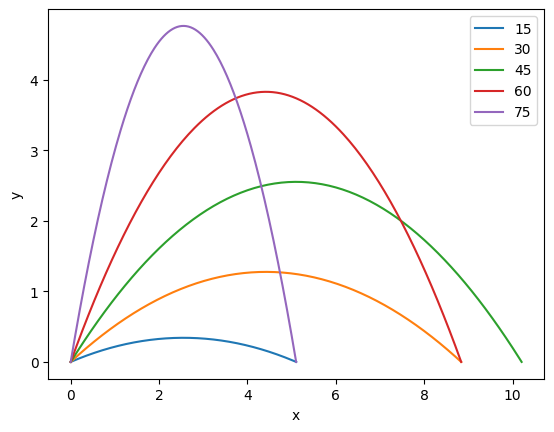

In [ ]:
g = 9.8 # m/s^2
v0 = 10 # m/s

x = lambda t, theta: v0*np.cos(theta)*t
y = lambda t, theta: v0*np.sin(theta)*t - 0.5*g*t**2

angles = np.radians([15, 30, 45, 60, 75])

for thi in angles:
    t = np.linspace(0, 2*v0*np.sin(thi)/g, 200 )
    plt.plot( x(t,thi), y(t,thi), label=f"{np.degrees(thi):.0f}")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

## Osciladores armónicos

$$
    x = A \cos(\omega t + \phi)
$$

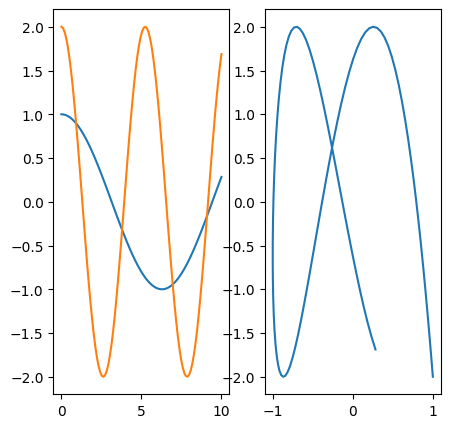

In [ ]:
x = lambda t, A, omega, phi: A*np.cos(omega*t + phi)
t = np.linspace(0,10, 100)

fig, ax = plt.subplots(1,2, figsize=(5,5))
ax[0].plot(t, x(t, 1, 0.5, 0.0))
ax[0].plot(t, x(t, 2, 1.2, 0.0))

ax[1].plot( x(t, 1, 0.5, 0.0), x(t, 2, 1.2, np.pi) )
